In this notebook you will:
- See a powerful custom diffusion model pipeline in action (with information on how to make our own version)
- Create our mini pipeline by:
  - Recapping the core ideas behind diffusion models
  - Loading in data from the Hub for training
  - Exploring how we add noise to the data with a scheduler
  - Creating and training the UNet model
  - Putting the pieces together into a working pipeline
- Edit and run a script for initializing longer training runs, that will handle:
  - Multi-GPU training via HF Accelerate
  - Experiment logging to track critical stats
  - Uploading the final model to the HF Hub

In [1]:
!pip install -qq -U diffusers datasets transformers accelerate ftfy pyarrow==9.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 873.1/873.1 kB 19.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
from huggingface_hub import notebook_login

notebook_login()

Install Git-LFS to upload the model checkpoints:

In [3]:
!sudo apt -qq install git-lfs
!git config --global credential.helper store

The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 52 not upgraded.
Need to get 3,908 kB of archives.
After this operation, 11.7 MB of additional disk space will be used.
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package git-lfs.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.4.1-1ubuntu0.4_amd64.deb ...
Unpacking git-lfs (3.4.1-1ubuntu0.4) ...
Setting up git-lfs (3.4.1-1ubuntu0.4) ...
Processing triggers for man-db (2.12.0-4build2) ...


Import libraries and define a few functions we'll use later in the notebook

In [11]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import PIL
from PIL import Image

def show_images(x: torch.Tensor, plot=False) -> PIL.Image:
  """For a image batch x, we make a grid and convert to PIL"""
  x = x * 0.5 + 0.5 # Map from (-1, 1) back to (0, 1) for inferencing
  grid = torchvision.utils.make_grid(x) # Takes all batch images and formats them next to eachother in the form of a large matrix/grid of images
  grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255 # Denormalize and turn to RGB for inferencing
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))

  # Same thing just plotted via matplotlib, instead of displaying the PIL.Image object
  if plot:
    plt.figure(figsize=(10, 10))
    plt.imshow(grid_im)
    plt.axis('off')
    plt.show()

  return grid_im

def make_grid(images, size=64):
  """For a list of PIL images, stack them together into a line for easy viewing"""
  output_im = Image.new("RGB", (size * len(images), size))
  for i, im in enumerate(images):
    output_im.paste(im.resize((size, size)), (i * size, 0))
  return output_im

# Added MPS functionality
if torch.backends.mps.is_available and torch.backends.mps.is_built():
  device = torch.device('mps')
else:
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Here's an example using a model trained on 13 photos of a dog.

First, we load the pipeline. This will download model weights etc. from the Hub. Since this will download several GB of data for a one-line demo, we are welcome to skip this cell and simply see the example output!

### Observation
For diffusion models like Stable Diffusion, `torch.float16` (floating_point) is used instead of `int` because neural networks rely on continuous mathematical functions, the same process LLMs use to train, also applies to diffusion models, because having weights and biases and activations limited to integers would ruin the model's ability to process data, resulting in visual noise instead of a generated image.

In [2]:
from diffusers import StableDiffusionPipeline

model_id = "sd-dreambooth-library/dog-ppt-model"

# Load the pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/584 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

NameError: name 'device' is not defined

Once the pipeline has finished loading, we can generate images with:

In [ ]:
generator = torch.Generator('cuda').manual_seed(41)

"""Create a list to hold the PIL.Image objects generated by the diffusion model"""
img_l = []

prompt = "an abstract and high quality image of sks dog in nature"
for i in [1, 5, 10, 15, 20, 30, 40, 50]:
  image = pipe(prompt, num_inference_steps=i, guidance_scale=7.5, generator=generator).images[0]
  img_l.append(image)

In [ ]:
for i, img in enumerate(img_l):
  print(f"--- Image {i+1} ---")
  print(f"--- Dimension {img.size} ---")
  print(f"--- Colour mode {img.mode} ---")
  display(img)

In [ ]:
type(image)

**Exercise**: Try it yourself either with different models or prompts. The `sks` token represents a unique identifier for the novel concept in this case - what happens if we leave that out? We can also experiment with changing the number of sampling steps (how low can we go?) and the `guidance_scale`, which determines how much the model will try to match the prompt.

There is a lot going into the pipeline! But for now let's take a look at how we can train a diffusion model from scratch.

In [ ]:
"""Another example"""
pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]

The core API of HF Diffusers is divided into **three** main components:
1. **Pipelines:** high-level classes designed to rapidly generate samples from popular trained diffusion models in a user-friendly fashion.
2. **Models:** popular architectures for training diffusion models, like [UNet](https://arxiv.org/abs/1505.04597).
3. **Schedulers:** various techniques for generating images from noise during inference as well as to generate noisy images for training.

Pipelines are great for end-users, but in this notebook we are also going to present what is going on under the hood! So, we're gonna build our own pipeline, but before that, I implemented a code snipped filled to the top with theory (100% not implemented just for practicing my markdown formatting skills :) )

**_(only the bravest might stand!)_**

---

### **Optional Snippet:** Granular and Mathy explanation of **DDPM** `(Denoising Diffusion Probabilistic Models)`

#### A. The Forward Pass (Noising)
Starting from a real data sample x₀ ~ q(x), the forward pass gradually adds Gaussian noise over a total of T timesteps according to a predefined variance schedule \(β<small>1</small>, β<small>2</small>, …, β<small>T</small>)

$$q(x_t \mid x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t}x_{t-1}, \beta_t\mathbf{I})$$ (the formula for **the diffusion** process)

A notable property of this formulation is that we can sample the noisy image ${x_t}$ at *any* arbitrary timestep t directly from the original image x₀, w/o stepping through the intermediate transitions.

#### B. The Backward Pass (Denoising)
The reverse process is the actual generative transition that we want the model to learn. Because the true posterior distribution $q(x_{t-1} \mid x_t)$ is mathematically intractable, we approximate it using a neural network ($θ$) (typically a U-Net architecture):

#### C. The Simplified Loss Function
Instead of forcing the network to predict the clean image or the direct mean ($μ_θ$), Ho et al. (2020) showed that it is highly stable to train the network ($𝜀_θ$) to predict the **exact noise 𝜀** added at timestep t.

The simplified MSE objective function is formulated as:

$$L_{\text{simple}}(\theta) = \mathbb{E}_{t, x_0, \epsilon} \left[ \Vert \epsilon - \epsilon_\theta(x_t, t) \Vert^2 \right] = \mathbb{E}_{t, x_0, \epsilon} \left[ \Vert \epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon, t) \Vert^2 \right]$$


In [6]:
from diffusers import DDPMPipeline

model_id = 'AventIQ-AI/ddpm-cifar10-32_unconditional_image_generation'

# Load the Oxford Flowers Diffuser (UNet2DModel trained on Oxford Flowers dataset - nelorth/oxford-flowers)
pipe = DDPMPipeline.from_pretrained(model_id).to(device)

# Create 8 images
images = pipe(batch_size=8).images

# View the results
make_grid(images)

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

NameError: name 'device' is not defined

### Step 2: Download a training dataset

For the following example, we'll use a dataset of images from the HF Hub.
Specifically, [a collection of 300 flower pictures](https://huggingface.co/datasets/Ambrosiussen/flower-dataset). This is a very small dataset, so I've also included commented out lines for a few larger options. But if you'd prefer to use your own collection of images, you can also use the commented-out code example to load in pictures from a folder instead.

In [5]:
from datasets import load_dataset
from torchvision import transforms as T
from torch.utils.data import DataLoader

dataset_id = 'Ambrosiussen/flower-dataset'

dataset = load_dataset(dataset_id, split='train')

# Or load images from a local folder
# dataset = load_dataset("imagefolder", data_dir="path/to/folder")

# We'll train on 32-pixel square images, but you can try larger sizes also
img_size = 32
# You can lower the batch size if you keep OOMing
batch_size = 32

# Data augmentations
preprocess = T.Compose(
    [
        T.Resize((img_size, img_size)), # Resize
        T.RandomHorizontalFlip(), # Randomly flip
        T.ToTensor(), # Convert to tensor (0, 1)
        T.Normalize([0.5], [0.5]), # Map to (-1, 1)
    ]
)

def transform(examples):
  images = [preprocess(image.convert('RGB')) for image in examples['image']]
  return {'images': images}

dataset.set_transform(transform) # Apply real time "on-the-fly" transform directly on the Dataset object, in-place

# Create a dataloader from the dataset to serve up the transformer images in batches
train_loader = DataLoader(
    dataset, batch_size=batch_size, shuffle=True,
)

README.md:   0%|          | 0.00/395 [00:00<?, ?B/s]

data/train-00000-of-00001-4f92d9da8dce37(…): reconstructing file:   0%|          |  0.00B / 11.7MB            

data/train-00000-of-00001-4f92d9da8dce37(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/300 [00:00<?, ? examples/s]

In [7]:
type(next(iter(train_loader)))

dict

We can grab a batch of images and view some of them like so:

X shape: torch.Size([8, 3, 32, 32])


/tmp/ipykernel_6361/3215470642.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


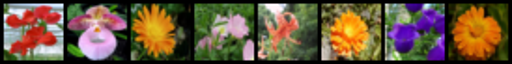

In [12]:
xb = next(iter(train_loader))['images'].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 64, 64))

We're sticking to a small dataset w/ 32 pixel images to keep training times manageable

### Step 3: Define the Scheduler

Our plan for training is to take these input images and add noise to them, then feed the noisy images to the model. And during inference, we will use the model predictions to iteratively remove noise. In `diffusers`, these processes are both handled by the **scheduler**.

The noise schedule determines how much noise is added at different timesteps. Here's how we might create a scheduler using the default settings for `DDPM` training and sampling:

In [4]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

The DDPM paper describes a corruption process that adds a small amount of noise for every 'timestep'. Given $x_{t-1}$ for some timestep, we can get the next (slightly more noisy) version $x_t$ with:<br><br>

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$<br><br>


That is, we take $x_{t-1}$, scale it by $\sqrt{1 - \beta_t}$ and add noise scaled by $\beta_t$. This $\beta$ is defined for every t according to some schedule, and determines how much noise is added per timestep. Now, we don't necessarily want to do this operation 500 times to get $x_{500}$ so we have another formula to get $x_t$ for any t given $x_0$: <br><br>

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, {(1 - \bar{\alpha}_t)} \mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$ and $\alpha_i = 1-\beta_i$<br><br>

The maths notation always looks scary! Luckily the scheduler handles all that for us. We can plot $\sqrt{\bar{\alpha}_t}$ (labelled as `sqrt_alpha_prod`) and $\sqrt{(1 - \bar{\alpha}_t)}$ (labelled as `sqrt_one_minus_alpha_prod`) to view how the input (x) and the noise are scaled and mixed across different timesteps:

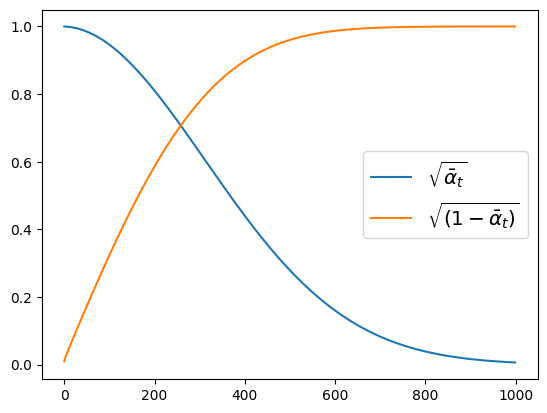

In [13]:
plt.plot(noise_scheduler.alphas_cumprod.cpu()**0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize='x-large');

**Exercise:** You can explore how this plot changes with different settings for beta_start, beta_end and beta_schedule by swapping in one of the commented-out options here:

In [ ]:
# One with too little noise added:
#noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.004)
# The 'cosine' schedule, which may be better for small image sizes:
#noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

Whichever scheduler we've chosen, we can now use it to add noise in different amounts using the `noise_scheduler.add_noise` function like so:

-> Batch size 8

Noisy X shape torch.Size([8, 3, 32, 32]) 



/tmp/ipykernel_6361/3215470642.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


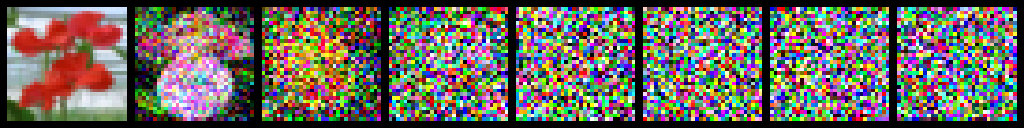

In [14]:
batch_size = xb.shape[0]
print(f'-> Batch size {batch_size}\n')
timesteps = torch.linspace(0, 999, batch_size).long().to(device) # Specific points ranging from completely clean (t=0) to highly corrupted (t=999)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print('Noisy X shape', noisy_xb.shape, '\n') # (B, C, H, W)
show_images(noisy_xb).resize((8*128, 128), resample=Image.NEAREST) # OBS: resample=Image.NEAREST uses nearest neighbor interpolation for resizing. This prevents the image from getting blurry, allowing us to clearly see the pixelated artifacts added at each timestep

### Step 4: Define the Model

Most diffusion models use architectures that are some variant of a [U-net]('https://arxiv.org/abs/1505.04597') and that's what we'll use in this notebook.

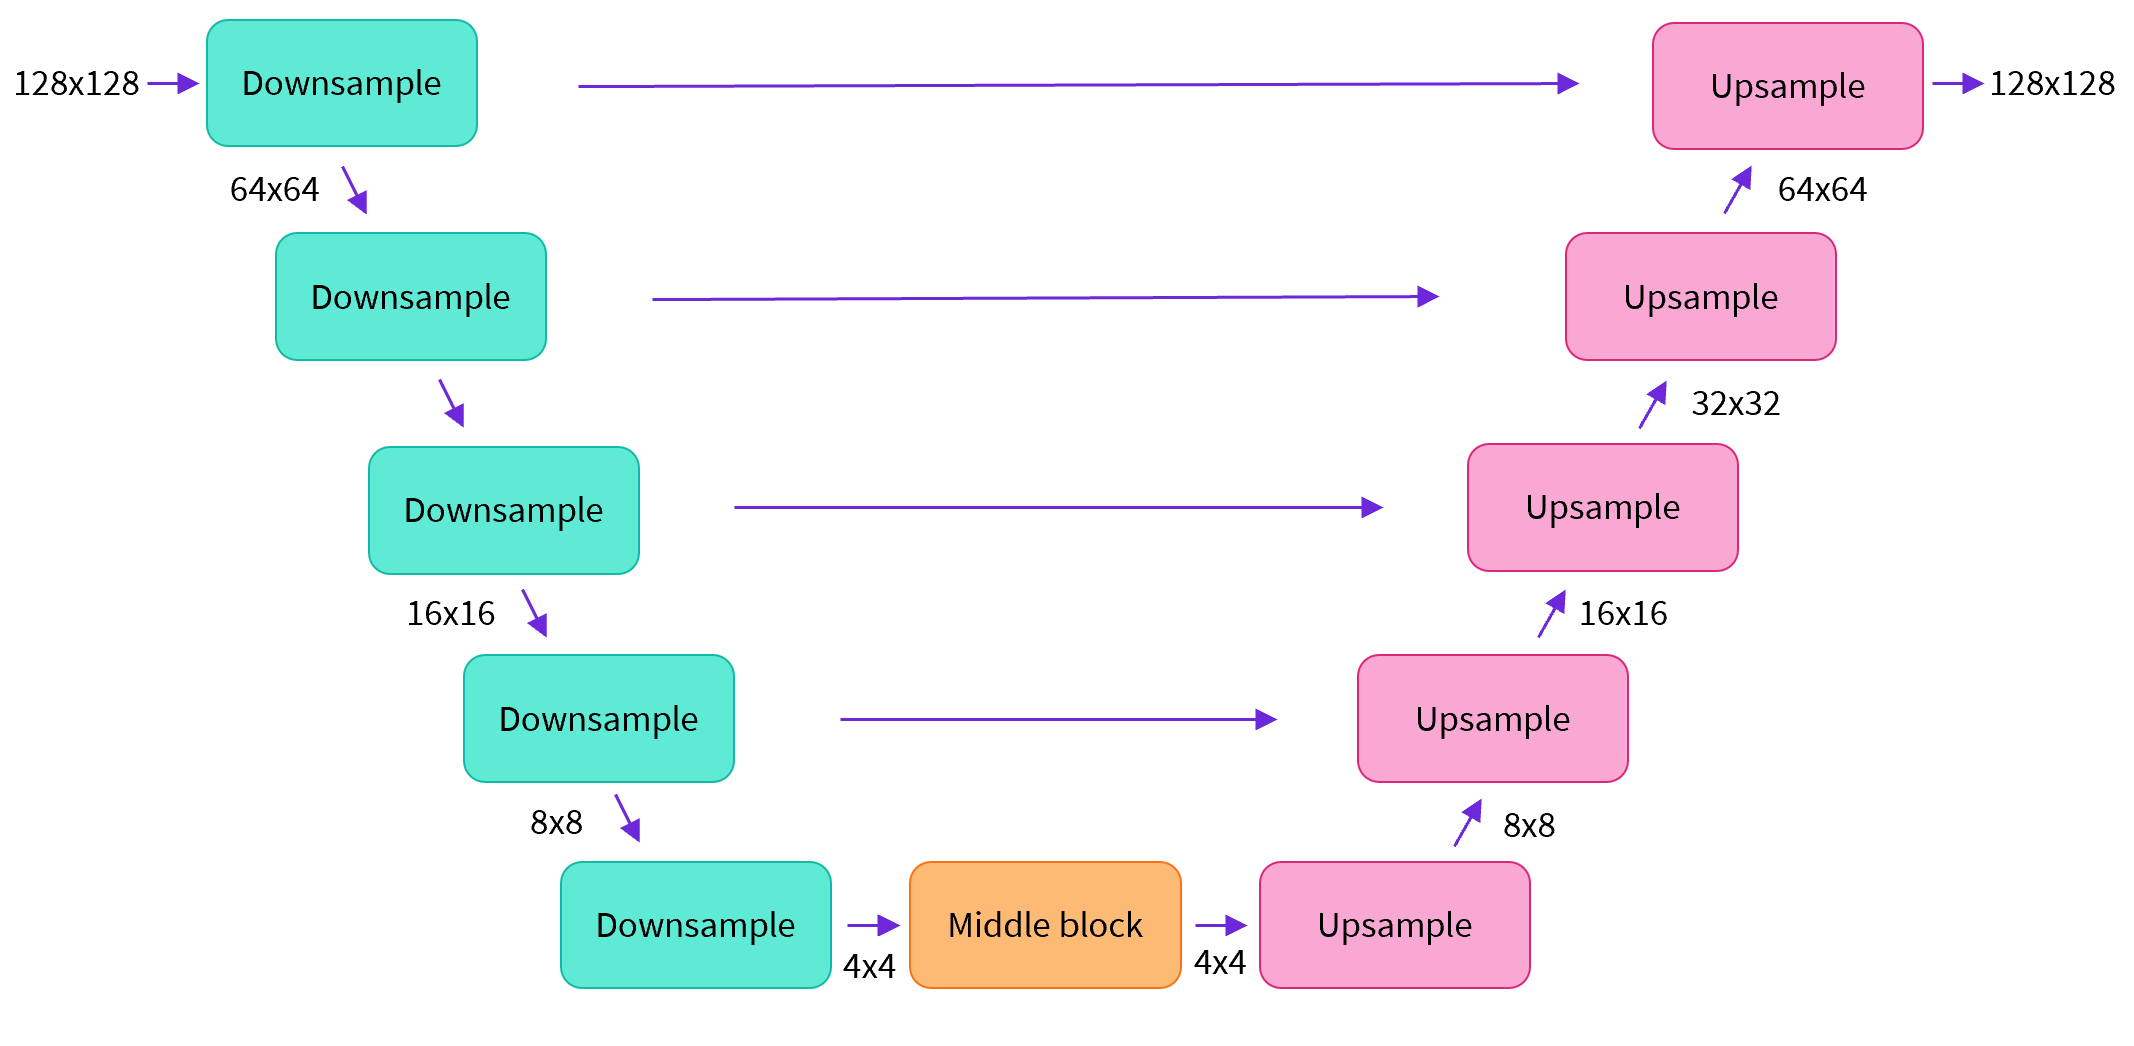

So basically:
- the model has the input image go through several blocks of ResNet layers, each of which halves the image size by 2
- then through the same number of blocks that upsample it again
- there are also skip connections linking the features on the downsample path to the corresponding layers in the upsample path

A key feature of this model is that it predicts images of the same size as the input, which is exactly what we need here.

Diffusers provides us a handy `UNet2DModel` class which creates the desired architecture in PyTorch.

Let's create a U-net for our desired image size. Note that `down_block_types` correspond to the downsampling blocks, and `up_block_types` are the upsampling blocks

In [15]:
from diffusers import UNet2DModel
image_size=32
# Create a model
model = UNet2DModel(
    sample_size=image_size, # target image resolution
    in_channels=3, # 3 for RGB
    out_channels=3, # number of output channels
    layers_per_block=2, # how many ResNet layers to user per UNet block
    block_out_channels=(64, 128, 128, 256), # Complexity of hidden layers, how many features/channels the model converges as its inputs go through the hidden layers
    down_block_types=(
        'DownBlock2D', # ResNet downsampling block
        'DownBlock2D',
        'AttnDownBlock2D', # ResNet downsampling block w/ spatial self-attention
        'AttnDownBlock2D',
    ),
    up_block_types=(
        'AttnUpBlock2D',
        'AttnUpBlock2D', # ResNet upsampling block w/ spatial self-attention
        'UpBlock2D',
        'UpBlock2D', # ResNet upsampling block
    ),
)
model.to(device);

In [16]:
"""Custom U-Net number of parameters"""
sum(p.numel() for p in model.parameters())

18536323

**Key:** When dealing w/ higher-resolution inputs we use more down and up-blocks, and keep the attention layers at the lowest resolution (bottom) layers to reduce memory usage.

We can check that passing in a batch of data and some random timesteps produces an output the same shape as the input data:

In [17]:
with torch.no_grad():
  model_pred = model(noisy_xb, timesteps).sample
model_pred.shape

torch.Size([8, 3, 32, 32])

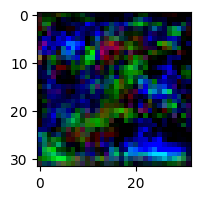

In [18]:
plt.figure(figsize=(2, 2))
plt.imshow(model_pred[0].permute(1, 2, 0).cpu().numpy()) # Note the channels last format for displaying

## Step 5: Create a Training Loop

We run through the data batch and update the parameters of the model each step using an optimizer

For each batch of data, we
- Sample some random timesteps
- Noise the data accordingly
- Feed the noisy data through the model
- Compare the model predictions w/ the target (i.e. the noise in this case)
- Update the model parameters via `loss.backward()` and `optimizer.step()`

During this process we also log the losses over time for later plotting.


In [19]:
EPOCHS=50

# Noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# Training loop
optim = torch.optim.AdamW(model.parameters(), lr=4e-4)

loss_l = []

for epoch in range(EPOCHS):
  for idx, batch in enumerate(train_loader):
    clean_img = batch['images'].to(device)
    # Sample noise to add to the images
    noise = torch.randn(clean_img.shape).to(clean_img.device)
    bs = clean_img.shape[0]

    # Sample a random timestep for each image
    timesteps = torch.randint(
        0, noise_scheduler.num_train_timesteps, (bs,), device=clean_img.device,
    ).long() # Generates from uniform distribution

    #print(f"-> Epoch {epoch} | {timesteps.shape}\n{timesteps[:50]}")
    #break

    # Add noise to the clean images according to the noise magnitude at each timestep
    noisy_img = noise_scheduler.add_noise(clean_img, noise, timesteps)

    # Get the model prediction
    noise_pred = model(noisy_img, timesteps, return_dict=False)[0]

    # Calculate the loss
    loss = F.mse_loss(noise_pred, noise)
    loss.backward(loss)
    loss_l.append(loss.item())

    # Update the model parameters with the optimizer
    optim.step()
    optim.zero_grad()

  if (epoch + 1) % 5 == 0:
    loss_last_epoch = sum(loss_l[-len(train_loader) :]) / len(train_loader)
    print(f"Epoch: {epoch+1}, loss: {loss_last_epoch}")

/usr/local/lib/python3.13/dist-packages/diffusers/configuration_utils.py:172: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch: 5, loss: 0.18205861300230025
Epoch: 10, loss: 0.16311139464378357
Epoch: 15, loss: 0.13848292380571364
Epoch: 20, loss: 0.14109767451882363
Epoch: 25, loss: 0.11305508092045784
Epoch: 30, loss: 0.11706005334854126
Epoch: 35, loss: 0.11584690660238266
Epoch: 40, loss: 0.10147748067975045
Epoch: 45, loss: 0.11678829044103622
Epoch: 50, loss: 0.10034282729029656


Plotting the loss, we see that the model rapidly improves initially and then continues to get better at a slower rate (which is obvious if we use a log scale as shown on the right):

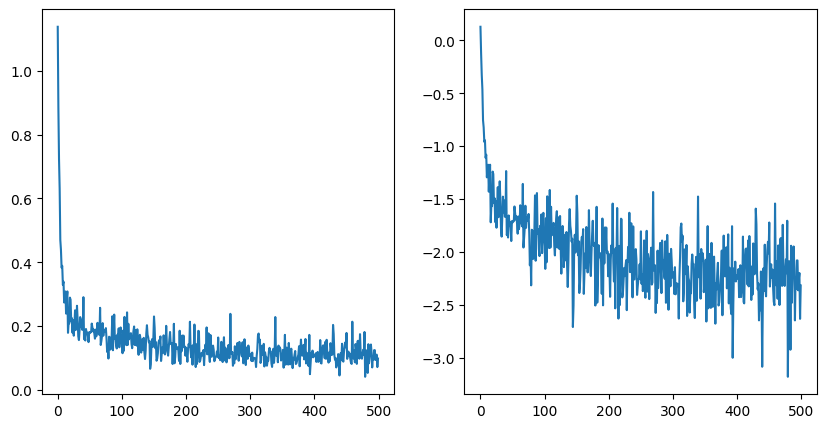

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(loss_l)
ax2.plot(np.log(loss_l))
plt.show()

In [ ]:
"""Here's how we load the earlier trained model, for the specific loaded pipeline purpose"""
model = pipe.unet

## Step 6: Inferencing/Generating Images

But how do we get images with this model?

### Option 1: Creating a pipeline:

In [ ]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)

In [ ]:
pipeline_output = image_pipe()
pipeline_output.images[0]

We can save a pipeline to a local folder like so:

In [ ]:
image_pipe.save_pretrained('my_custom_pipeline')

In [ ]:
!ls my_custom_pipeline

The `scheduler` and `unet` subfolders contain everything needed to re-create those components. For example, inside the `unet` folder we'll find the model weights (`diffusion_pytorch_model.bin`) alongside a config file which specifies the UNet architectures used.

In [ ]:
!ls my_custom_pipeline/unet/

Together, these files contain everything needed to recreate the pipeline. We can manually upload them to the hub and share the pipeline with others, or check out the code to do this via the API (the next section)

We can push it to hub like so

In [ ]:
image_pipe.push_to_hub('your-user-name/desired-name')

### Option 2: Writing a Sampling Loop

We begin w/ random noise, and run through the scheduler timesteps from most to least noisy, removing a small amount of noise each step based on the model prediction:

In [ ]:
# Random starting point (8 random images):
sample = torch.randn(8, 3, 32, 32).to(device) # (B, C, H, W)

for i, t in enumerate(noise_scheduler.timesteps):
  # Get model prediction
  with torch.no_grad():
    residual = model(sample, t).sample

  # Update sample w/ step
  sample = noise_scheduler.step(residual, t, sample).prev_sample

show_images(sample)

The `noise_scheduler.step()` function does the mathematics required to update the `sample` appropriately. There are a number of sampling methods, which we will explore together in the following modules of this `project-learning series`

## Scaling up with HF Accelerate

- - -
Here is a useful official hugging face diffusers python script that covers most of the boilerplate needed for larger-scale training and for using the `accelerate library`

**To note:** The following part of the notebook wasn't actually run and tested, since it required changing some versions of the libraries used

In [ ]:
!wget https://github.com/huggingface/diffusers/raw/main/examples/unconditional_image_generation/train_unconditional.py

In [ ]:
"""Get our trained model full name from the hub"""
from huggingface_hub import get_full_repo_name

model_name = 'Flower-UNet2D-pipeline'
hub_model_id = get_full_repo_name(model_name)
hub_model_id

In [ ]:
# The first --mixed_precision argument configures Accelerate
!accelerate launch \
  --num_processes=1 \
  --num_machines=1 \
  --mixed_precision=fp16 \
  --dynamo_backend=no \
  train_unconditional.py \
  --dataset_name="Ambrosiussen/flower-dataset" \
  --resolution=64 \
  --output_dir="Flower-UNet2D-pipeline" \
  --train_batch_size=32 \
  --num_epochs=50 \
  --gradient_accumulation_steps=1 \
  --learning_rate=1e-4 \
  --lr_warmup_steps=500 \
  --mixed_precision=fp16 # Configures the Diffusers training script

This is the result of the training run:

In [ ]:
pipeline = DDPMPipeline.from_pretrained(hub_model_id).to(device)
images = pipeline(batch_size=8).images
make_grid(images)

# Exercises:

- Training an unconditional diffusion model on a new dataset, and improve the already implemented/applied UNet2D architecture from this notebook
- Try out DreamBooth to create our own customized Stable Diffusion pipeline
- Modify the training script to explore different UNet hyperparameters (number of layers, channels etc.), different noise schedules etc.
- Check out the next Diffusion-Models-from-Scratch notebook for a different take on the core ideas we've covered here